In [20]:
import ROOT
import numpy as np
from array import array
import math
import matplotlib.pyplot as plt

# Example data (logarithmic bin centers)
bin_centers = [1, 2, 4, 8, 16]     # for example
counts = [5, 12, 18, 9, 3]

def find_log_bin_edges(bin_centers):
    bin_edges = []
    for i in range(len(bin_centers) - 1):
        edge = math.sqrt(bin_centers[i] * bin_centers[i + 1])
        bin_edges.append(edge)
    # Add first and last edges
    first_edge = bin_centers[0]**2 / bin_edges[0]
    last_edge = bin_centers[-1]**2 / bin_edges[-1]
    bin_edges = [first_edge] + bin_edges + [last_edge]
    return np.array(bin_edges)
    

def bin_counts_to_hist(bin_centers, counts, hist_name):

    # Compute logarithmic bin edges
    # Assume geometric spacing between centers
    bin_edges = []
    for i in range(len(bin_centers) - 1):
        edge = math.sqrt(bin_centers[i] * bin_centers[i + 1])
        bin_edges.append(edge)
    # Add first and last edges
    first_edge = bin_centers[0]**2 / bin_edges[0]
    last_edge = bin_centers[-1]**2 / bin_edges[-1]
    bin_edges = [first_edge] + bin_edges + [last_edge]
    
    # Convert to ROOT array
    edges_array = array('d', bin_edges)
    
    # Create histogram
    hist = ROOT.TH1D(hist_name, "Logarithmic Binning;X axis;Counts", len(bin_centers), edges_array)
    
    # Fill bin contents
    for i, count in enumerate(counts):
        hist.SetBinContent(i + 1, count)

    return hist

In [35]:
mult_HLLHC_lumi = 3000/5/365/24/3600 # 1/fb/s
mult_angle = 1/2 * (1.1 - 0.65)/5 * 0.5/2./np.pi
mult_HLLHC_lumi, mult_angle
correction = mult_HLLHC_lumi*mult_angle
correction

6.813139687153054e-08

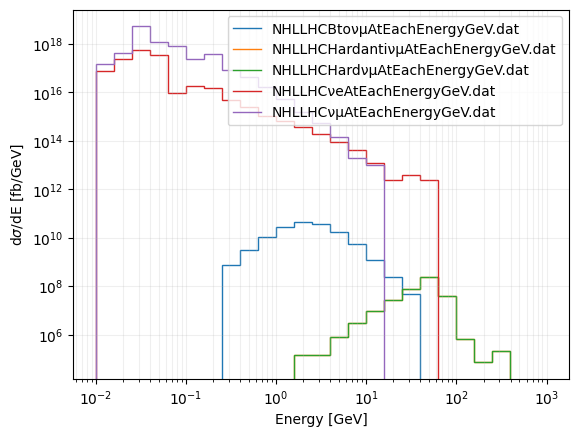

In [48]:
files = ["NHLLHCBtoνμAtEachEnergyGeV.dat",
"NHLLHCHardantiνμAtEachEnergyGeV.dat",
"NHLLHCHardνμAtEachEnergyGeV.dat",
"NHLLHCνeAtEachEnergyGeV.dat",
"NHLLHCνμAtEachEnergyGeV.dat",]
for filename in files:
    data=np.loadtxt("flux_data/"+filename, delimiter=",")
    bin_centers = data[:,0]
    counts = data[:,1]
    bin_edges = find_log_bin_edges(bin_centers)
    # print(bin_centers, counts)
    plt.stairs(counts,bin_edges, label=filename)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel("Energy [GeV]")
plt.ylabel("d$\sigma$/dE [fb/GeV]")
plt.grid(which="both", alpha=0.2)

1.902587519025875e-05
1.902587519025875e-05
1.902587519025875e-05
6.813139687153054e-08
6.813139687153054e-08


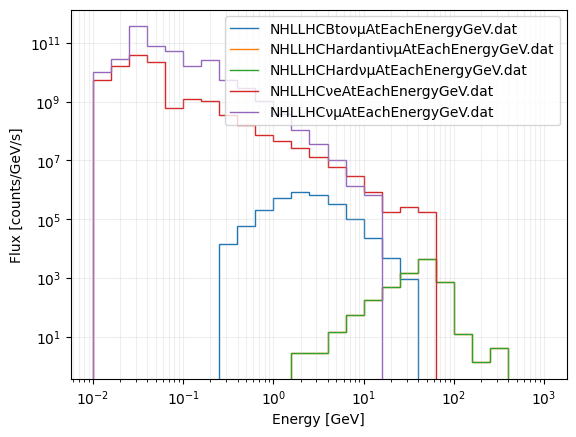

In [44]:
for filename in files:
    data=np.loadtxt("flux_data/"+filename, delimiter=",")
    bin_centers = data[:,0]
    counts = data[:,1]
    bin_edges = find_log_bin_edges(bin_centers)
    # bin_width = bin_edges[1:]-bin_edges[:-1]

    k = mult_HLLHC_lumi if "NHLLHCν" not in filename else mult_HLLHC_lumi*mult_angle
    print(k)
    
    plt.stairs(counts*k, bin_edges, label=filename)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel("Energy [GeV]")
plt.ylabel("Flux [counts/GeV/s]")
plt.grid(which="both", alpha=0.2)

In [49]:
# Save to ROOT file
output = ROOT.TFile("flux_data/combined_flux.root", "RECREATE")

for i,filename in enumerate(files):
    data=np.loadtxt("flux_data/"+filename, delimiter=",")
    bin_centers = data[:,0]
    counts = data[:,1]
    bin_edges = find_log_bin_edges(bin_centers)
    bin_width = bin_edges[1:]-bin_edges[:-1]
    k = mult_HLLHC_lumi if "NHLLHCν" not in filename else mult_HLLHC_lumi*mult_angle

    if i<=2: # Remove the last bin
        hist = bin_counts_to_hist(bin_centers[:-1], counts[:-1]*k, filename.split(".")[0])
        
    else:
        hist = bin_counts_to_hist(bin_centers, counts*k, filename.split(".")[0])
    hist.Write()
    
output.Close()

print("Histogram with logarithmic binning saved to flux_data/combined_flux.root")

Histogram with logarithmic binning saved to flux_data/combined_flux.root
